**Import niezbednych bibliotek**

In [1]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt

Deklaracje stałych zgodnych z treścią zadania

In [10]:
initial_price = 120000
annual_price_increase = 0.05
annual_deposit_growth = 0.12
monthly_deposit_growth = annual_deposit_growth/12
number_years = 5
number_of_periods = number_years * 12


## Ad 1
obliczenie ile bedzie wynosić cena mieszkania za 5 lat

In [11]:
final_price = initial_price * (1 + annual_price_increase) ** number_years
print(f"1. Orientacyjna cena mieszkania za 5 lat wyniesie: {final_price:.2f} zł")

1. Orientacyjna cena mieszkania za 5 lat wyniesie: 153153.79 zł


## Ad 2
obliczenia jakie kwoty muszę wpłacać co miesiac do banku by na koniec zadanego okresy uzbierac na mieszkanie 

Aby to policzyć uzyjemy funkcji npf.pmt()

Parametry funkcji npf.pmt(rate, nper, pv, fv, when):

rate - stopa procentowa dla jednego okresu
nper - liczba okresów (u nas: 60 miesięcy)  
pv - (Present Value) wartość obecna lokaty, zaczynamy od zera, więc wynosi 0  
fv - (Future Value) wartość, którą chcemy dostać na koniec (cena mieszkania za 5 lat).  
when - (0 - oznacza platnosc na koniec miesiaca).

In [17]:
monthly_payment = npf.pmt(rate=monthly_deposit_growth, 
                            nper=number_of_periods, 
                            pv=0, 
                            fv=-final_price, 
                            when=0)
print(f"2. Musisz wpłacać do banku na koniec każdego miesiąca: {monthly_payment:.2f} zł")

2. Musisz wpłacać do banku na koniec każdego miesiąca: 1875.28 zł


## Ad 3
przygotowanie danych do wykresu
do obliczenia wartosci lokaty w czasie uzyjemy funkcji npf.fv(rate, nper, pmt, pv)  

rate - stopa procentowa dla jednego okresu dla lokaty  
nper - liczba okresów (u nas: 60 miesięcy)  
pmt  - miesięczna wpłata  
pv - (Present Value) wartość obecna lokaty, zaczynamy od zera, więc wynosi 0  


In [23]:

periods = np.arange(0, number_of_periods + 1)
price =  np.linspace(initial_price, final_price, number_of_periods + 1)
depisit_value = npf.fv(rate=monthly_deposit_growth, 
                        nper=periods, 
                        pmt=-monthly_payment, 
                        pv=0)

wykorzystanie otrzumanych danych do wyświetlenia wykresów 

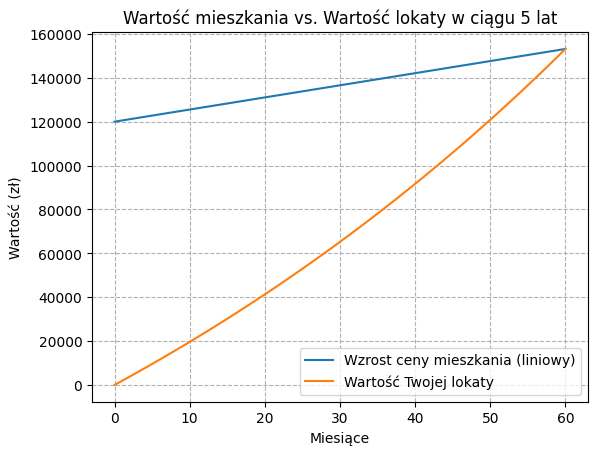

In [ ]:
plt.plot(periods, price, label="Wzrost ceny mieszkania (liniowy)")
plt.plot(periods, depisit_value, label="Wartość Twojej lokaty")
plt.xlabel("Miesiące")
plt.ylabel("Wartość (zł)")
plt.title("Wartość mieszkania vs. Wartość lokaty w ciągu 5 lat")

plt.grid(True, linestyle='--')

plt.legend()
plt.show()